In [1]:
import os
import json

import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt

In [10]:
data_dir_path = "../data/realAWSCloudwatch"
dfs = {}

for filename in os.listdir(data_dir_path):
    if filename.startswith("ec2_cpu_utilization"):
        df = pd.read_csv(os.path.join(data_dir_path, filename))
        df["timestamp"] = pd.to_datetime(df["timestamp"])
        dfs[filename] = df

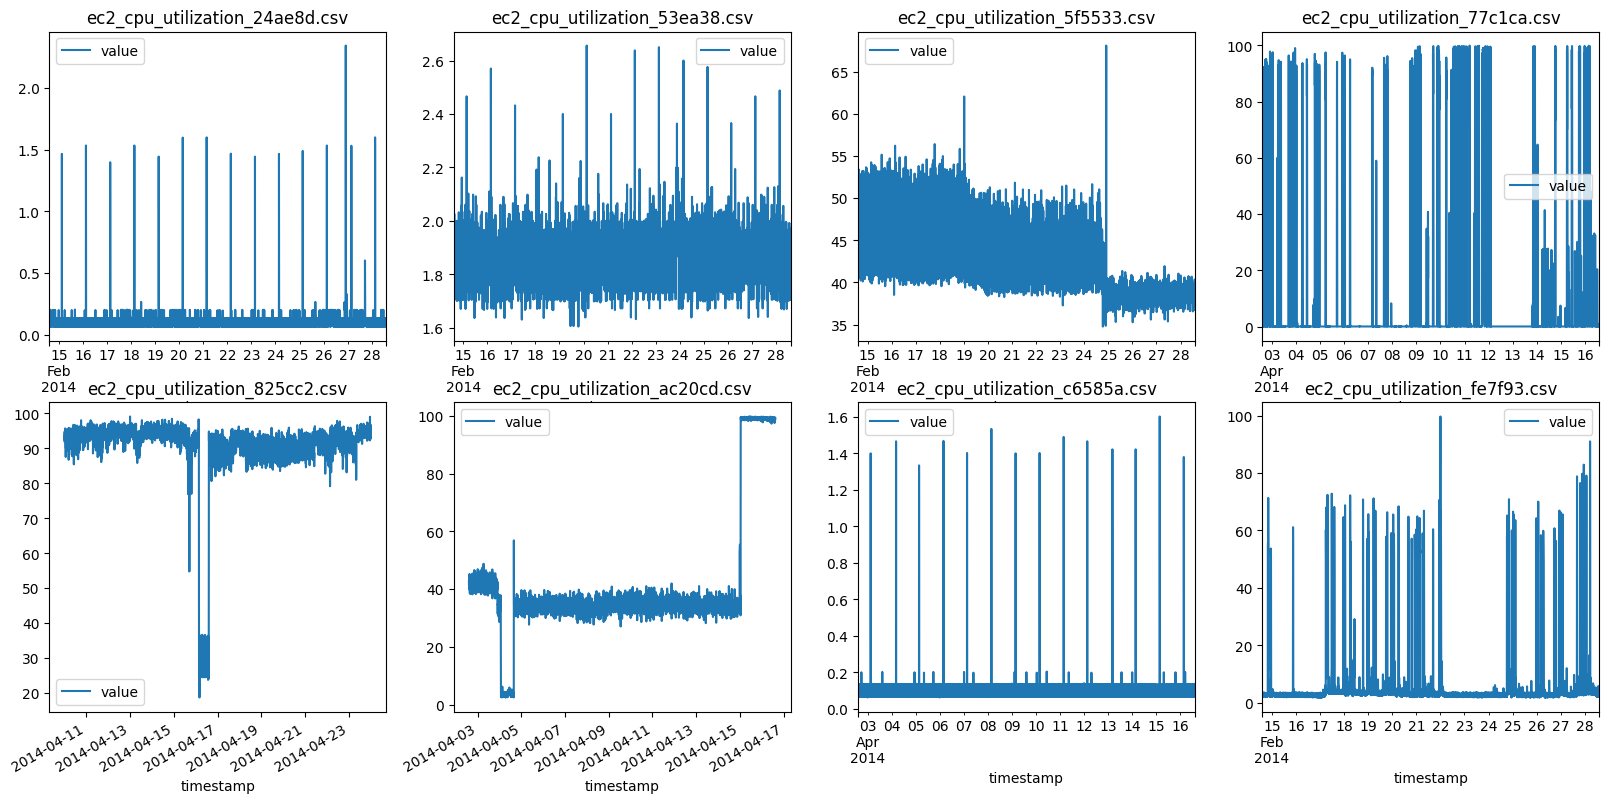

In [12]:
fig, axs = plt.subplots(2, 4, figsize=(20, 10))
axs.flat

for i, filename in enumerate(dfs.keys()):
    df = dfs[filename]
    df.plot(x="timestamp", y="value", ax=axs.flat[i], title=filename)

plt.show()

The cpu utilization data have very different patterns

In [31]:
labels_path = "../data/labels/combined_labels.json"

with open(labels_path, "r") as f:
    labels = json.load(f)

for filename, df in dfs.items():
    key = f"realAWSCloudwatch/{filename}"
    anomaly_timestamps = pd.to_datetime(labels.get(key, []), errors="coerce")
    df["anomaly_label"] = df["timestamp"].isin(anomaly_timestamps).astype("bool")
    print(df[df["anomaly_label"] == True][["timestamp", "value", "anomaly_label"]])

               timestamp  value  anomaly_label
3547 2014-02-26 22:05:00  2.344           True
3777 2014-02-27 17:15:00  0.602           True
               timestamp  value  anomaly_label
1496 2014-02-19 19:10:00  2.058           True
2659 2014-02-23 20:05:00  1.966           True
               timestamp   value  anomaly_label
1271 2014-02-19 00:22:00  62.056           True
2930 2014-02-24 18:37:00  34.766           True
               timestamp   value  anomaly_label
1966 2014-04-09 10:15:00  34.866           True
               timestamp   value  anomaly_label
1626 2014-04-15 15:44:00  76.874           True
1768 2014-04-16 03:34:00  24.432           True
               timestamp   value  anomaly_label
3575 2014-04-15 00:49:00  88.202           True
Empty DataFrame
Columns: [timestamp, value, anomaly_label]
Index: []
               timestamp   value  anomaly_label
765  2014-02-17 06:12:00  53.922           True
2131 2014-02-22 00:02:00  99.668           True
2602 2014-02-23 15:17:00 

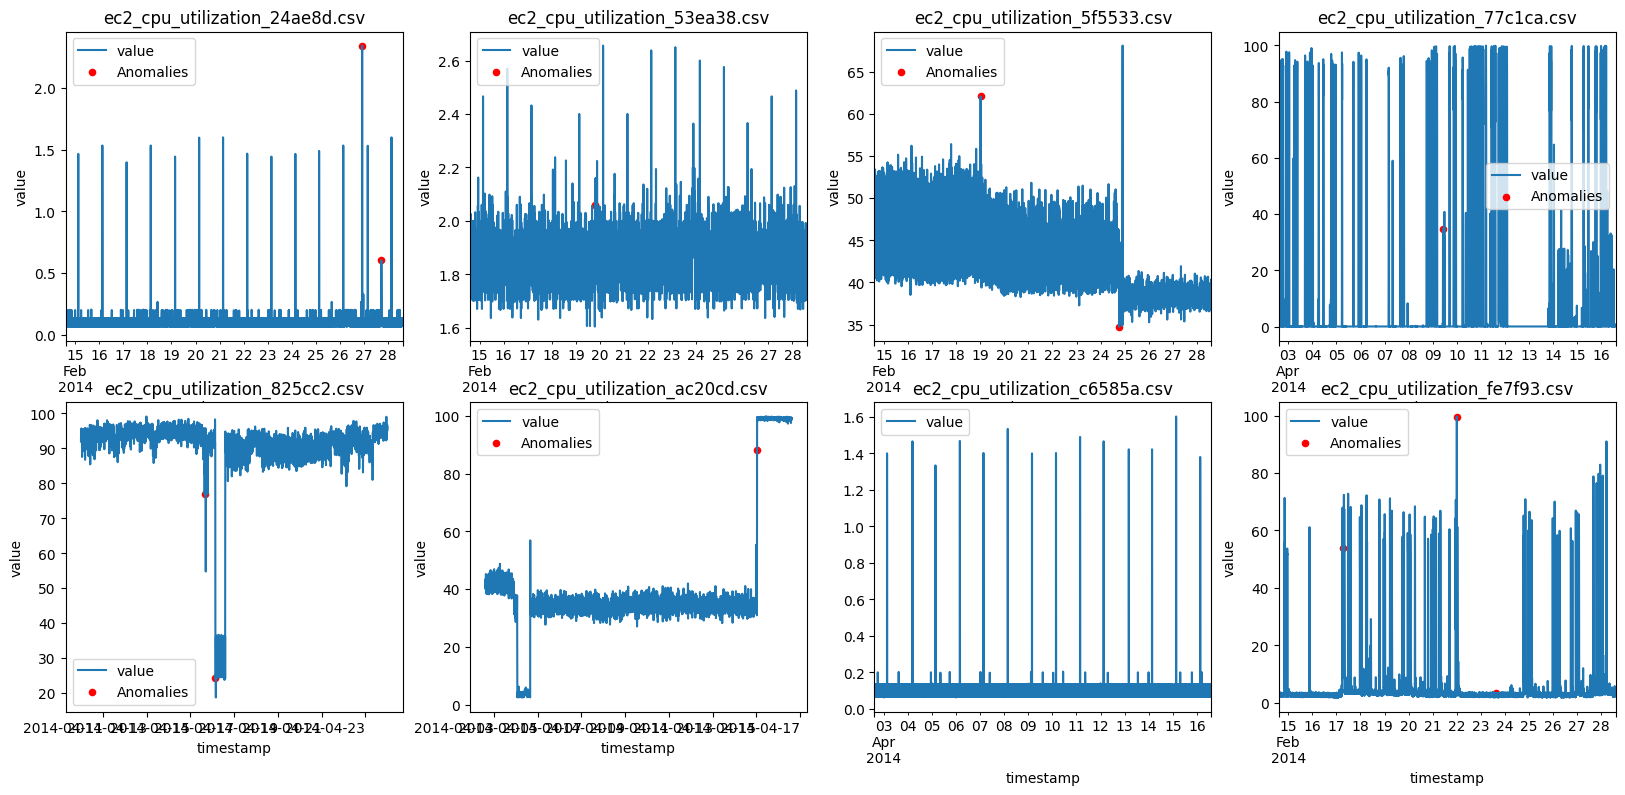

In [34]:
labels_path = "../data/labels/combined_labels.json"

with open(labels_path, "r") as f:
    labels = json.load(f)

fig, axs = plt.subplots(2, 4, figsize=(20, 10))

for i, filename in enumerate(dfs.keys()):
    df = dfs[filename]
    df.plot(x="timestamp", y="value", ax=axs.flat[i], title=filename)
    anomalies = df[df['anomaly_label'] == True]
    if not anomalies.empty:
        anomalies.plot.scatter(x="timestamp", y="value", ax=axs.flat[i], color='red', label='Anomalies')
    axs.flat[i].legend()

plt.show()

Looks like anomalies mark unusual peaks and drops, but regular peaks is a normal behavior 